In [1]:
import os
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.chdir('/hpc/scratch/977879/roman_urdu_sentiment')

print("All libraries imported successfully")

2026-03-16 13:41:40.808892: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 13:41:40.808983: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 13:41:40.809003: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 13:41:42.686790: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All libraries imported successfully


In [2]:
df = pd.read_csv('rusad_cleaned.csv')

print(df.shape)
print(df['label_encoded'].value_counts())
df.head()

(10999, 2)
label_encoded
1    5699
0    5300
Name: count, dtype: int64


,cleaned_text,label_encoded
0,ab achanak khawaja saad rafique ko khiyaal aag...,0
1,adha drama to censor hi hojaye gaa khaas tor p...,0
2,bekaar fuzool end moti budhi laila jeet gayee ...,0
3,choor kasuri choor jhootay ka moo kaala,0
4,gali gali mein shor hai gaaanjaaaa shair chor hai,0


In [3]:
X = df['cleaned_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8799
Testing samples: 2200


In [4]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=100, padding='post', truncating='post')

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (8799, 100)
Testing shape: (2200, 100)


In [5]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

2026-03-16 13:42:32.287126: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8032 MB memory:  -> device: 0, name: Tesla P100-SXM2-16GB, pci bus id: 0000:84:00.0, compute capability: 6.0


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 128)          1280000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                        

In [6]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10


2026-03-16 13:42:51.254147: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2026-03-16 13:42:56.951561: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f4dd8137570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-16 13:42:56.951629: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla P100-SXM2-16GB, Compute Capability 6.0
2026-03-16 13:42:57.346782: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-16 13:42:58.801235: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


248/248 [==============================] - 34s 76ms/step - loss: 0.5579 - accuracy: 0.7030 - val_loss: 0.4521 - val_accuracy: 0.8011
Epoch 2/10
248/248 [==============================] - 8s 33ms/step - loss: 0.3259 - accuracy: 0.8673 - val_loss: 0.4453 - val_accuracy: 0.7898
Epoch 3/10
248/248 [==============================] - 5s 20ms/step - loss: 0.1921 - accuracy: 0.9332 - val_loss: 0.5557 - val_accuracy: 0.7977
Epoch 4/10
248/248 [==============================] - 5s 19ms/step - loss: 0.1234 - accuracy: 0.9578 - val_loss: 0.6998 - val_accuracy: 0.7818
Epoch 5/10
248/248 [==============================] - 4s 17ms/step - loss: 0.0763 - accuracy: 0.9744 - val_loss: 1.0120 - val_accuracy: 0.7966


In [8]:
y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

69/69 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.80      1060
    Positive       0.82      0.79      0.80      1140

    accuracy                           0.80      2200
   macro avg       0.80      0.80      0.80      2200
weighted avg       0.80      0.80      0.80      2200



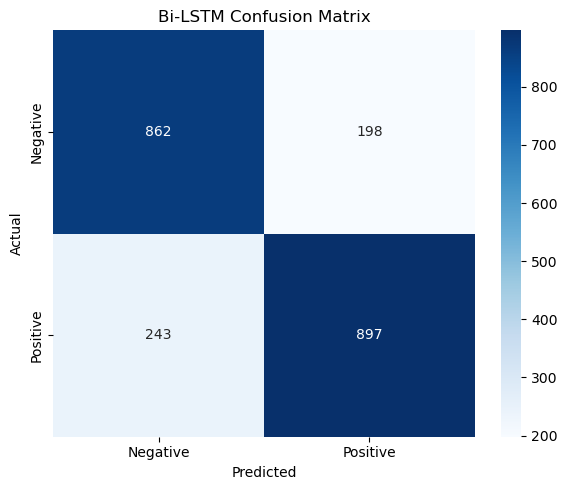

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Bi-LSTM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('BiLSTM_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

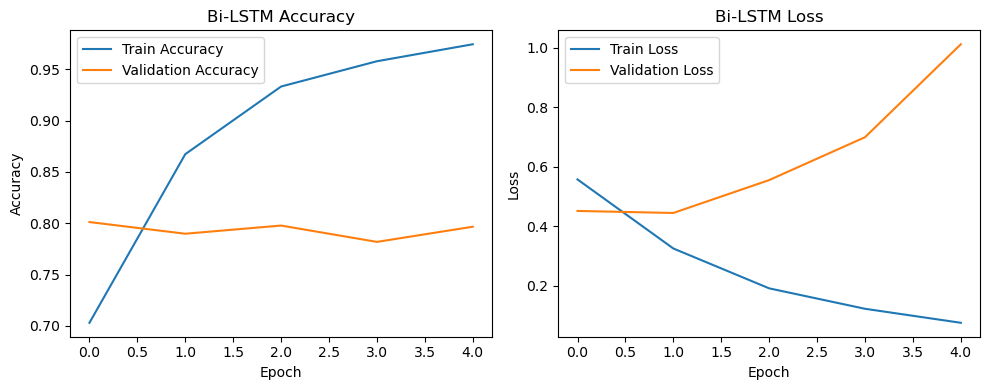

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Bi-LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Bi-LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('BiLSTM_training_history.png', dpi=150, bbox_inches='tight')
plt.show()